# Deterministic physics-based route difficulty (GPX)

**Intensity density** (mechanical work per km):

$$\text{density} = \frac{W_{\mathrm{grav}} + \left(\text{kinetic\_factor} \cdot W_{\mathrm{roll}}\right)}{d_{\mathrm{km}}}$$

with:  
$W_{\mathrm{grav}} = m \, g \, \sum \Delta h^{+}$, $W_{\mathrm{roll}} = C_{\mathrm{rr}} \, m \, g \, d$, 

and:  
$\text{kinetic\_factor} = 1 + \beta \, (\mathrm{SI}_{p90} - 1)^{\gamma}$ 

applied **only** to $W_{\mathrm{roll}}$.

**Environment:** use the venv at `scraper/physics/.venv` (see `scraper/physics/requirements.txt`). From `scraper/physics`: `python -m venv .venv`, activate, `pip install -r requirements.txt`.

Scores **1–10** are **relative to this corpus** (percentile normalization), not universal units.

## Ideas and terminology

This notebook estimates **how mechanically demanding** a route is from **GPX geometry only** (lat/lon/elevation). It does **not** know about surface type, exposure, bike handling skill, or weather. Treat the result as **mechanical intensity**, not “how scary” or “how skilled you must be.”

### Intensity density (J/km)

We combine two idealized work terms and divide by horizontal distance:

- **Gravitational work** \(W_{\mathrm{grav}}\): proportional to **elevation gained** on a smoothed profile (only **uphill** segments count in the sum). Think: climbing stores energy you had to supply.
- **Rolling resistance work** \(W_{\mathrm{roll}}\): proportional to **distance** on the ground, as if you were always rolling with coefficient \(C_{\mathrm{rr}}\).

**Sinuosity** (how much the path wiggles relative to a straight chord) is used only to **scale up rolling work** on twisty segments via a **kinetic factor**. Psychological difficulty is outside this model unless it shows up as path length or elevation.

### Sinuosity index (SI)

Along the track we look at windows of roughly fixed **arc length** (e.g. 50 m, matching `si_window_m` in `PhysicsParams`). For each window, \(\mathrm{SI} = \dfrac{\text{arc length}}{\text{chord length}}\). A straight segment \(\to 1\); detours \(\mathrm{SI} > 1\). We summarize many windows with **SI at the 90th percentile** (\(\mathrm{SI}_{p90}\)) so occasional straight sections do not hide a mostly winding trail.

### Kinetic factor

\(\text{kinetic\_factor} = 1 + \beta \, \bigl(\max(0,\, \mathrm{SI}_{p90} - 1)\bigr)^{\gamma}\). It is **1** on straight cruising and grows when the route is winding. It multiplies **only** \(W_{\mathrm{roll}}\), not \(W_{\mathrm{grav}}\), so climbing and flat distance contribute through different channels.

### From density to score 1–10

Densities are mapped to **1–10** using **percentiles of this corpus** (e.g. clip between P5 and P95, then linear scale). So **10** means “among these scraped routes, this one is near the top of the pack,” not an absolute worldwide rating.

### Groopy labels (sanity plots only)

Groopy **difficulty** is a **human tag**. We map Hebrew labels to numbers **only** to compare visually against the physics score. Mismatch is expected: people mix fitness, fear, trail surface, and memory into one label.


In [117]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_scraper_root() -> Path:
    """Locate directory containing scrape.mjs (works from repo root or scraper/physics/notebooks)."""
    here = Path.cwd().resolve()
    for d in [here, *here.parents]:
        if (d / "scrape.mjs").is_file():
            return d
    raise FileNotFoundError(
        "Could not find scraper/scrape.mjs; run the notebook with cwd under the RYDO repo."
    )


SCRAPER_ROOT = find_scraper_root()
PHYSICS_ROOT = SCRAPER_ROOT / "physics"
if str(PHYSICS_ROOT) not in sys.path:
    sys.path.insert(0, str(PHYSICS_ROOT))

from ml.physics_difficulty import (
    PhysicsParams,
    load_gpx_metrics,
)

print("SCRAPER_ROOT =", SCRAPER_ROOT)
print("PHYSICS_ROOT =", PHYSICS_ROOT)

SCRAPER_ROOT = C:\DEV\RYDO\scraper
PHYSICS_ROOT = C:\DEV\RYDO\scraper\physics


## Constants (tunable)

| Symbol / field | Role |
|---|---|
| `mass_kg`, `g` | Rider+bike mass and gravity; scale **both** work terms. |
| `c_rr` | Rolling resistance coefficient; higher → **more flat-road work** per km. |
| `elev_smooth_window` | Odd window (points) for **rolling median elevation** before Δh; reduces GPS jitter. |
| `min_segment_m` | Ignore **very short** horizontal segments when summing distance (avoids divide-by-near-zero noise). |
| `si_window_m` | Arc length used for each **local sinuosity** window (meters along the track). |
| `beta`, `gamma` | Shape of the **kinetic factor** vs \(\mathrm{SI}_{p90}\); higher → winding routes tax rolling work more. |
| `norm_low_pct`, `norm_high_pct` | **Percentile band** for mapping density → 1–10; wider band = less saturation at the ends. |

Defaults in code: $m=85\,\mathrm{kg}$, $g=9.80665$, $C_{\mathrm{rr}}=0.02$, elevation window 5 points, SI window $50\,\mathrm{m}$, $\beta=\gamma=1$, normalization P5–P95.

In [118]:
PARAMS = PhysicsParams(
    mass_kg=85.0,
    g=9.80665,
    c_rr=0.02,
    elev_smooth_window=5,
    min_segment_m=0.5,
    si_window_m=50.0,
    beta=1.0,
    gamma=1.0,
    norm_low_pct=5.0,
    norm_high_pct=95.0,
)
PARAMS

PhysicsParams(mass_kg=85.0, g=9.80665, c_rr=0.02, elev_smooth_window=11, min_segment_m=0.5, si_window_m=400.0, beta=1.0, gamma=1.0, norm_low_pct=5.0, norm_high_pct=95.0)

### Corpus inputs (`tracks.csv` + GPX)

Each scrape output folder `scraper/out_*/` has a **`tracks.csv`** (UTF-8-BOM) with metadata and a **`gpx/`** path to the track file. The notebook keeps rows where the GPX exists and computes metrics **per route**. Duplicate **`pid`** rows are collapsed to the first occurrence.


## Load corpus

Glob `scraper/out_*/tracks.csv`, UTF-8 with BOM. Keep rows with a real `gpxLocalPath` and existing GPX file.

In [119]:
rows_meta: list[dict] = []
for out_dir in sorted(SCRAPER_ROOT.glob("out_*")):
    csv_path = out_dir / "tracks.csv"
    if not csv_path.is_file():
        continue
    meta = pd.read_csv(csv_path, encoding="utf-8-sig", dtype=str)
    meta["_out_dir"] = str(out_dir.resolve())
    rows_meta.append(meta)

if not rows_meta:
    raise FileNotFoundError(f"No out_*/tracks.csv under {SCRAPER_ROOT}")

tracks = pd.concat(rows_meta, ignore_index=True)
tracks["pid"] = pd.to_numeric(tracks["pid"], errors="coerce")
tracks = tracks.dropna(subset=["pid"]).copy()
tracks["pid"] = tracks["pid"].astype(int)

def resolve_gpx(row) -> Path | None:
    raw = row.get("gpxLocalPath")
    if raw is None or pd.isna(raw):
        gpx_rel = ""
    else:
        gpx_rel = str(raw).strip()
    if not gpx_rel:
        return None
    base = Path(str(row["_out_dir"]))
    p = (base / Path(gpx_rel)).resolve()
    return p if p.is_file() else None

tracks["_gpx_path"] = tracks.apply(resolve_gpx, axis=1)
valid = tracks["_gpx_path"].notna()
print("Total rows:", len(tracks), "| With GPX file:", valid.sum())
tracks_ok = tracks.loc[valid].copy()
tracks_ok.head(3)

Total rows: 664 | With GPX file: 407


,pid,url,pageTitle,trackName,openDate,area,rideType,length,hoursNet,climb,...,startPoint,milestones,attraction,season,descriptionText,gpxUrl,gpxLocalPath,openerName,_out_dir,_gpx_path
2,2448,https://www.groopy.co.il/trackinfo.aspx?pid=2448,מסלול רכיבת אופניים | רמת צבי - כוכב הירדן (בה...,רמת צבי - כוכב הירדן (בהשראת אבי מור),21/12/2019,גליל תחתון והעמקים,XC,"29 ק""מ",2.5 שעות,550 מטר,...,מול גן הילדים במושב רמת צבי,"מבצר כוכב הירדן, גן הפסלים יגאל תומרקין, יד לי...",NaN,לא בגשם או כשהאדמה רטובה!!,NaN,https://www.groopy.co.il/files/maslul/2448gps.gpx,gpx/2448.gpx,אהוד גנני,C:\DEV\RYDO\scraper\out_2450-2151,C:\DEV\RYDO\scraper\out_2450-2151\gpx\2448.gpx
3,2447,https://www.groopy.co.il/trackinfo.aspx?pid=2447,מסלול רכיבת אופניים | ביתרונות רוחמה (בהשראת א...,ביתרונות רוחמה (בהשראת איתן כורך),21/12/2019,דרום הר חברון,XC,"28 ק""מ",2.5 שעות,400 מטר,...,החנייה בכניסה לקיבוץ רוחמה,NaN,NaN,NaN,NaN,https://www.groopy.co.il/files/maslul/2447gps.gpx,gpx/2447.gpx,אהוד גנני,C:\DEV\RYDO\scraper\out_2450-2151,C:\DEV\RYDO\scraper\out_2450-2151\gpx\2447.gpx
7,2443,https://www.groopy.co.il/trackinfo.aspx?pid=2443,מסלול רכיבת אופניים | סביבות החולה,סביבות החולה,29/11/2019,גליל עליון,XC,"38 ק""מ",4.0 שעות,190 מטר,...,יסוד המעלה,NaN,NaN,"אפילו בקייץ, הרבה מים",מסלול טיול שמבוסס על טיול של חיים ב.ע(יסוד המע...,https://www.groopy.co.il/files/maslul/2443gps.gpx,gpx/2443.gpx,ברקאי,C:\DEV\RYDO\scraper\out_2450-2151,C:\DEV\RYDO\scraper\out_2450-2151\gpx\2443.gpx


### What “per-route physics” computes

For each GPX we **parse points**, **smooth elevation** (rolling median) to reduce GPS noise, measure **horizontal distance** with a sphere (haversine), accumulate **positive height gain**, estimate **rolling sinuosity windows** and a **global** path/chord ratio, apply the **kinetic factor**, then form **intensity density** in J/km. Exported columns include work splits and SI summaries so you can inspect outliers.


## Per-route physics metrics

Skip rows where GPX parse fails (logged in `errors`).

In [120]:
results: list[dict] = []
errors: list[tuple[int, str]] = []

def _csv_text(val) -> str:
    if val is None or (isinstance(val, float) and pd.isna(val)):
        return ""
    t = str(val).strip()
    if t.lower() in ("nan", "none", "<na>"):
        return ""
    return t

for _, row in tracks_ok.iterrows():
    pid = int(row["pid"])
    if pid == 2760 or pid == 2486: continue
    gpx_path = row["_gpx_path"]
    try:
        m = load_gpx_metrics(gpx_path, PARAMS)
        results.append(
            {
                "pid": pid,
                "trackName": row.get("trackName") or "",
                "difficulty_groopy": _csv_text(row.get("difficulty")),
                "difficulty_technical": _csv_text(row.get("technicalDifficulty")),
                "distance_km": m["distance_km"],
                "elevation_gain_m_smoothed": m["elevation_gain_m_smoothed"],
                "W_grav_J": m["W_grav_J"],
                "W_roll_J": m["W_roll_J"],
                "si_p90": m["si_p90"],
                "si_mean": m["si_mean"],
                "si_max": m["si_max"],
                "si_global": m["si_global"],
                "kinetic_factor": m["kinetic_factor"],
                "intensity_density_J_per_km": m["intensity_density_J_per_km"],
                "gpx_path": m["gpx_path"],
            }
        )
    except Exception as e:
        errors.append((pid, str(e)))

res = pd.DataFrame(results)
if len(res):
    res = res.drop_duplicates(subset=["pid"], keep="first")
print("Computed:", len(res), "| Errors:", len(errors))
if errors[:5]:
    print("Sample errors:", errors[:5])
res.sort_values("intensity_density_J_per_km", ascending=False).head(15)

Computed: 387 | Errors: 18
Sample errors: [(2209, "'utf-8' codec can't decode byte 0xfa in position 0: invalid start byte"), (2175, "'utf-8' codec can't decode byte 0xcd in position 0: invalid continuation byte"), (2173, 'No track points in C:\\DEV\\RYDO\\scraper\\out_2450-2151\\gpx\\2173.gpx'), (2548, "'utf-8' codec can't decode byte 0xff in position 2: invalid start byte"), (2542, "'utf-8' codec can't decode byte 0xff in position 2: invalid start byte")]


,pid,trackName,difficulty_groopy,difficulty_technical,distance_km,elevation_gain_m_smoothed,W_grav_J,W_roll_J,si_p90,si_mean,si_max,si_global,kinetic_factor,intensity_density_J_per_km,gpx_path
288,2698,רכיבת יום הזיכרון לחללי צהל באיזור נגבה תשפג מ...,בינוני-קל,קל,38.847882,227.219872,189402.589409,647644.890468,5.322071,3.104590,69.330925,1653.078493,5.322071,93601.362353,C:\DEV\RYDO\scraper\out_2750-2651\gpx\2698.gpx
312,2668,ירושלים מעיינות ומנהרת האופניים,למתקדמים,בינוני,21.562147,694.800000,579161.135700,359469.126924,3.697905,2.458924,211.902623,15122.806764,3.697905,88508.985687,C:\DEV\RYDO\scraper\out_2750-2651\gpx\2668.gpx
262,2733,"קנדה קשתות ומח""ר",בינוני,קל,20.341384,391.000000,325924.012750,339117.417440,4.279880,5.184329,365.088150,99.784102,4.279880,87373.895682,C:\DEV\RYDO\scraper\out_2750-2651\gpx\2733.gpx
201,2635,"בעיבדיס רוקד השטן....רכיבת יום הזכרון תשפ""ב",בינוני,קל,32.992953,578.500000,482217.497125,550035.577732,4.029104,2.320964,150.154897,3101.162444,4.029104,81786.189295,C:\DEV\RYDO\scraper\out_2650-2551\gpx\2635.gpx
47,2335,בל נשכח את לוחמי תשח - בעקבות שיירת יחיעם,בינוני,בינוני,30.872446,611.500000,509725.150375,514683.968126,3.769414,3.102143,228.829202,640.694386,3.769414,79351.738795,C:\DEV\RYDO\scraper\out_2450-2151\gpx\2335.gpx
313,2667,"ביריה לשדה אליעזר-מעיינות וקברות צדיקים(עפ""י ר...",בינוני-קשה,קל,39.113645,560.500000,467213.322625,652075.510439,3.606879,2.114881,176.379485,4.769224,3.606879,72076.407940,C:\DEV\RYDO\scraper\out_2750-2651\gpx\2667.gpx
311,2669,עין כרם חנדק וספיר,בינוני,בינוני,22.772407,773.650000,644887.755663,379645.736391,2.569860,2.039337,263.618570,1990.949669,2.569860,71161.747831,C:\DEV\RYDO\scraper\out_2750-2651\gpx\2669.gpx
13,2395,כפר בלום אל הנחלים בשביל הנכדים,בינוני,בינוני,26.500687,228.432473,190413.371683,441801.032676,3.675410,4.353796,359.009538,1924.933141,3.675410,68459.110132,C:\DEV\RYDO\scraper\out_2450-2151\gpx\2395.gpx
385,2755,סינגל הבוסתן בכרמל,למתקדמים,בינוני,23.849373,578.200000,481967.427550,397600.177364,2.852435,1.709691,7.976960,5641.251565,2.852435,67762.626919,C:\DEV\RYDO\scraper\out_2840-2750\gpx\2755.gpx
204,2630,עולים בכיסלון יורדים בדיפנבייקר,בינוני,קל,26.626051,1039.750000,866699.468687,443891.017190,2.104548,1.445772,12.088431,3676.652898,2.104548,67636.373353,C:\DEV\RYDO\scraper\out_2650-2551\gpx\2630.gpx


### Corpus normalization (1–10)

Scores use **robust percentiles** (e.g. P5–P95) of **finite** densities so a few broken GPXs or NaNs do not collapse the whole band. Rows with non-finite density get a missing score. Changing **`norm_low_pct`** / **`norm_high_pct`** changes how stretched the 1–10 scale is (a wider band puts more routes in the middle scores).


## Normalize to score 1–10 (corpus percentiles)

Uses **P5–P95** on finite densities via `np.nanpercentile` (robust to outliers and NaN rows).

In [121]:
if len(res) == 0:
    raise RuntimeError("No routes computed; check GPX files and errors above.")

# Inline nan-safe normalization so stale kernel imports cannot poison scores.
dens = pd.to_numeric(res["intensity_density_J_per_km"], errors="coerce").to_numpy(dtype=float)
n_fin = int(np.isfinite(dens).sum())
n_tot = len(dens)
print(f"Finite densities: {n_fin} / {n_tot}")
if n_fin == 0:
    raise RuntimeError("All intensity_density_J_per_km are non-finite; check GPX parsing.")
p_lo = float(np.nanpercentile(dens, PARAMS.norm_low_pct))
p_hi = float(np.nanpercentile(dens, PARAMS.norm_high_pct))
if not np.isfinite(p_lo) or not np.isfinite(p_hi):
    raise RuntimeError("Normalization percentiles are NaN")
if p_hi <= p_lo + 1e-15:
    p_hi = p_lo + 1e-15
clipped = np.clip(dens, p_lo, p_hi)
scores = 1.0 + (clipped - p_lo) / (p_hi - p_lo) * 9.0
res = res.assign(physics_score_1_10=scores)
print(
    f"Normalization band (J/km): P{PARAMS.norm_low_pct:g} = {p_lo:,.1f}, "
    f"P{PARAMS.norm_high_pct:g} = {p_hi:,.1f}"
)
res.sort_values("physics_score_1_10", ascending=False).head(15)

Finite densities: 288 / 387
Normalization band (J/km): P5 = 27,071.2, P95 = 62,344.3


,pid,trackName,difficulty_groopy,difficulty_technical,distance_km,elevation_gain_m_smoothed,W_grav_J,W_roll_J,si_p90,si_mean,si_max,si_global,kinetic_factor,intensity_density_J_per_km,gpx_path,physics_score_1_10
49,2333,סינגל להב הישן והחדש,בינוני,בינוני,25.723671,736.350000,613795.771837,428847.166032,2.594446,1.717179,9.119607,5657.926527,2.594446,67113.921056,C:\DEV\RYDO\scraper\out_2450-2151\gpx\2333.gpx,10.0
47,2335,בל נשכח את לוחמי תשח - בעקבות שיירת יחיעם,בינוני,בינוני,30.872446,611.500000,509725.150375,514683.968126,3.769414,3.102143,228.829202,640.694386,3.769414,79351.738795,C:\DEV\RYDO\scraper\out_2450-2151\gpx\2335.gpx,10.0
313,2667,"ביריה לשדה אליעזר-מעיינות וקברות צדיקים(עפ""י ר...",בינוני-קשה,קל,39.113645,560.500000,467213.322625,652075.510439,3.606879,2.114881,176.379485,4.769224,3.606879,72076.407940,C:\DEV\RYDO\scraper\out_2750-2651\gpx\2667.gpx,10.0
312,2668,ירושלים מעיינות ומנהרת האופניים,למתקדמים,בינוני,21.562147,694.800000,579161.135700,359469.126924,3.697905,2.458924,211.902623,15122.806764,3.697905,88508.985687,C:\DEV\RYDO\scraper\out_2750-2651\gpx\2668.gpx,10.0
311,2669,עין כרם חנדק וספיר,בינוני,בינוני,22.772407,773.650000,644887.755663,379645.736391,2.569860,2.039337,263.618570,1990.949669,2.569860,71161.747831,C:\DEV\RYDO\scraper\out_2750-2651\gpx\2669.gpx,10.0
198,2639,Haifa Cable Express PLUS (בהשראת אדוארדו אוקסמן),בינוני,קל,45.898045,1073.770000,895057.358409,765180.300582,2.782334,1.792251,84.947058,9.682366,2.782334,65886.131163,C:\DEV\RYDO\scraper\out_2650-2551\gpx\2639.gpx,10.0
185,2468,עדולם אפילו בגשם,בינוני-קשה,קל,32.000117,1011.000000,842734.467750,533483.713809,2.441204,1.568483,105.509952,672.398376,2.441204,67033.415296,C:\DEV\RYDO\scraper\out_2550-2451\gpx\2468.gpx,10.0
204,2630,עולים בכיסלון יורדים בדיפנבייקר,בינוני,קל,26.626051,1039.750000,866699.468687,443891.017190,2.104548,1.445772,12.088431,3676.652898,2.104548,67636.373353,C:\DEV\RYDO\scraper\out_2650-2551\gpx\2630.gpx,10.0
288,2698,רכיבת יום הזיכרון לחללי צהל באיזור נגבה תשפג מ...,בינוני-קל,קל,38.847882,227.219872,189402.589409,647644.890468,5.322071,3.104590,69.330925,1653.078493,5.322071,93601.362353,C:\DEV\RYDO\scraper\out_2750-2651\gpx\2698.gpx,10.0
201,2635,"בעיבדיס רוקד השטן....רכיבת יום הזכרון תשפ""ב",בינוני,קל,32.992953,578.500000,482217.497125,550035.577732,4.029104,2.320964,150.154897,3101.162444,4.029104,81786.189295,C:\DEV\RYDO\scraper\out_2650-2551\gpx\2635.gpx,10.0


### Reading the density histogram

This plot shows the **distribution of intensity density (J/km)** across routes that were computed successfully. The vertical lines mark the **percentile band** used to map density to the 1–10 score. If the band is very narrow or huge outliers dominate, consider adjusting **`norm_low_pct` / `norm_high_pct`** or inspecting GPX quality.


## Histogram of intensity density

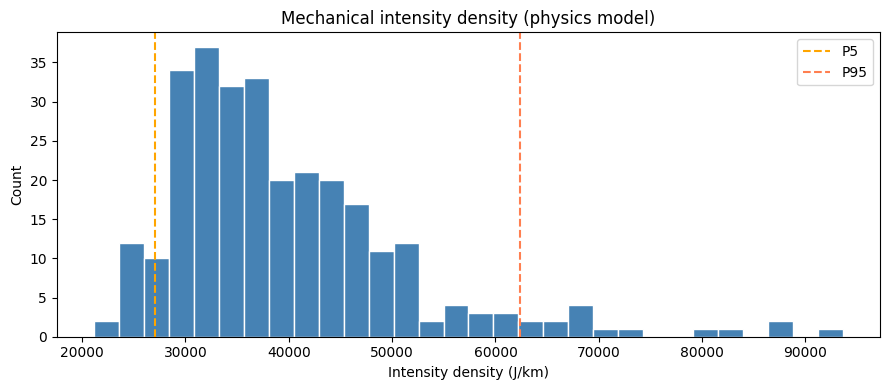

In [122]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(res["intensity_density_J_per_km"], bins=30, color="steelblue", edgecolor="white")
ax.axvline(p_lo, color="orange", linestyle="--", label=f"P{PARAMS.norm_low_pct:g}")
ax.axvline(p_hi, color="coral", linestyle="--", label=f"P{PARAMS.norm_high_pct:g}")
ax.set_xlabel("Intensity density (J/km)")
ax.set_ylabel("Count")
ax.legend()
ax.set_title("Mechanical intensity density (physics model)")
plt.tight_layout()
plt.show()

## Export `physics_scores.csv`

Writes a UTF-8-BOM CSV next to this notebook under **`scraper/physics/physics_scores.csv`**, one row per route with **IDs, physics score, density, distance, work splits, sinuosity summaries, Groopy overall + technical difficulty text, and GPX path**. Use this file for downstream apps, QA, or merging into a database — re-run the notebook after changing **`PARAMS`** or the scrape corpus.

In [123]:
out_csv = PHYSICS_ROOT / "physics_scores.csv"
export_cols = [
    "pid",
    "trackName",
    "physics_score_1_10",
    "intensity_density_J_per_km",
    "distance_km",
    "elevation_gain_m_smoothed",
    "W_grav_J",
    "W_roll_J",
    "kinetic_factor",
    "si_p90",
    "si_mean",
    "si_max",
    "si_global",
    "difficulty_groopy",
    "difficulty_technical",
    "gpx_path",
]
res.sort_values("pid", ascending=False)[export_cols].to_csv(out_csv, index=False, encoding="utf-8-sig")
print("Wrote", out_csv.resolve())

Wrote C:\DEV\RYDO\scraper\physics\physics_scores.csv


## Sanity only: Groopy difficulty vs physics score

Groopy stores **overall** (`difficulty`) and **technical** (`technicalDifficulty`) strings per route. Both use the same Hebrew label vocabulary in many cases, but they answer different questions (effort/fitness vs trail skill surface). This section does **not** treat either as ground truth.

- **Ordinal mapping**: Hebrew labels are converted to numbers **only for visualization** (e.g. easy → low, advanced → high). The spacing is arbitrary.
- **What to look for**: a **rough upward cloud** means tags and mechanical intensity move together sometimes; **wide scatter** means tags encode things the physics model ignores (skill, exposure, surface, memory).
- **Correlation lines** printed below are **diagnostic**, not a target to maximize.

Rows without a mapped label or a finite physics score are dropped. **RTL note:** axis labels use `python-bidi` so Hebrew reads correctly in matplotlib.

Groopy technical labels with no ordinal mapping (add to GROOPY_ORD): ['קשה']


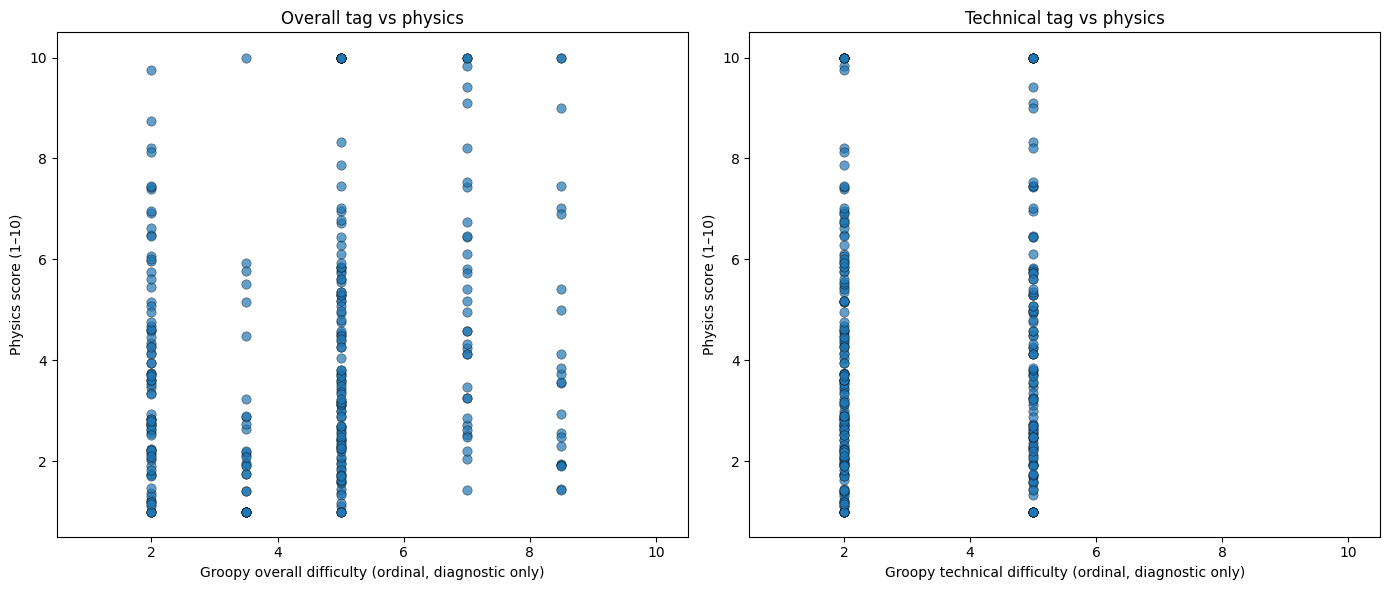

Plotted rows (overall): 282 / 387
Plotted rows (technical): 270 / 387
Pearson r (Groopy overall ordinal vs physics score): 0.1821
Spearman rho (Groopy overall ordinal vs physics score): 0.1732
Pearson r (Groopy overall ordinal vs log intensity density): 0.1880

Pearson r (Groopy technical ordinal vs physics score): 0.0186
Spearman rho (Groopy technical ordinal vs physics score): 0.0163
Pearson r (Groopy technical ordinal vs log intensity density): 0.0157


In [124]:
GROOPY_ORD = {
    "קל": 2.0,
    "מתאים למתחילים": 2.0,
    "בינוני-קל": 3.5,
    "בינוני": 5.0,
    "בינוני-קשה": 7.0,
    "למתקדמים": 8.5,
}


def groopy_to_ord(s) -> float | None:
    if s is None or (isinstance(s, float) and pd.isna(s)):
        return None
    t = str(s).strip()
    if not t or t.lower() == "nan":
        return None
    return GROOPY_ORD.get(t)


plot_df = res.copy()
plot_df["groopy_ord"] = plot_df["difficulty_groopy"].map(groopy_to_ord)
plot_df["technical_ord"] = plot_df["difficulty_technical"].map(groopy_to_ord)

miss = plot_df.loc[
    plot_df["difficulty_groopy"].astype(str).str.strip().ne("")
    & plot_df["groopy_ord"].isna(),
    "difficulty_groopy",
]
unmapped = miss.unique().tolist()
if unmapped:
    print("Groopy overall labels with no ordinal mapping (add to GROOPY_ORD):", unmapped)

miss_t = plot_df.loc[
    plot_df["difficulty_technical"].astype(str).str.strip().ne("")
    & plot_df["technical_ord"].isna(),
    "difficulty_technical",
]
unmapped_t = miss_t.unique().tolist()
if unmapped_t:
    print("Groopy technical labels with no ordinal mapping (add to GROOPY_ORD):", unmapped_t)

plot_clean = plot_df.dropna(subset=["groopy_ord", "physics_score_1_10"]).copy()
plot_clean = plot_clean[
    np.isfinite(plot_clean["groopy_ord"]) & np.isfinite(plot_clean["physics_score_1_10"])
]

plot_clean_t = plot_df.dropna(subset=["technical_ord", "physics_score_1_10"]).copy()
plot_clean_t = plot_clean_t[
    np.isfinite(plot_clean_t["technical_ord"])
    & np.isfinite(plot_clean_t["physics_score_1_10"])
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]
if len(plot_clean):
    ax.scatter(
        plot_clean["groopy_ord"],
        plot_clean["physics_score_1_10"],
        s=45,
        alpha=0.7,
        edgecolors="k",
        linewidths=0.35,
    )
    ax.set_xlabel("Groopy overall difficulty (ordinal, diagnostic only)")
    ax.set_ylabel("Physics score (1–10)")
    ax.set_title("Overall tag vs physics")
    ax.set_xlim(0.5, 10.5)
    ax.set_ylim(0.5, 10.5)
else:
    ax.text(
        0.5,
        0.5,
        "No finite (overall Groopy, physics) pairs — check mapping.",
        ha="center",
        va="center",
        transform=ax.transAxes,
    )

ax = axes[1]
if len(plot_clean_t):
    ax.scatter(
        plot_clean_t["technical_ord"],
        plot_clean_t["physics_score_1_10"],
        s=45,
        alpha=0.7,
        edgecolors="k",
        linewidths=0.35,
    )
    ax.set_xlabel("Groopy technical difficulty (ordinal, diagnostic only)")
    ax.set_ylabel("Physics score (1–10)")
    ax.set_title("Technical tag vs physics")
    ax.set_xlim(0.5, 10.5)
    ax.set_ylim(0.5, 10.5)
else:
    ax.text(
        0.5,
        0.5,
        "No finite (technical Groopy, physics) pairs — check mapping.",
        ha="center",
        va="center",
        transform=ax.transAxes,
    )

plt.tight_layout()
plt.show()

print("Plotted rows (overall):", len(plot_clean), "/", len(res))
print("Plotted rows (technical):", len(plot_clean_t), "/", len(res))


def _corr_block(df: pd.DataFrame, xcol: str, label: str) -> None:
    if len(df) < 3:
        print(f"Too few paired rows for {label} correlation (need ≥3).")
        return
    xo = df[xcol].to_numpy(dtype=float)
    ys = df["physics_score_1_10"].to_numpy(dtype=float)
    pearson_r = float(np.corrcoef(xo, ys)[0, 1])
    rx = pd.Series(xo).rank(method="average").to_numpy()
    ry = pd.Series(ys).rank(method="average").to_numpy()
    spearman_rho = float(np.corrcoef(rx, ry)[0, 1])
    print(f"Pearson r ({label} vs physics score): {pearson_r:.4f}")
    print(f"Spearman rho ({label} vs physics score): {spearman_rho:.4f}")
    dens_p = df["intensity_density_J_per_km"].to_numpy(dtype=float)
    mden = np.isfinite(dens_p) & (dens_p > 0)
    if int(mden.sum()) >= 3:
        ld = np.log(dens_p[mden])
        xod = xo[mden]
        print(
            f"Pearson r ({label} vs log intensity density): {float(np.corrcoef(xod, ld)[0, 1]):.4f}"
        )


_corr_block(plot_clean, "groopy_ord", "Groopy overall ordinal")
print()
_corr_block(plot_clean_t, "technical_ord", "Groopy technical ordinal")

## More diagnostics (model vs Groopy)

The next cell is **self-contained**: it rebuilds the paired table from `res` (same Groopy mapping as the scatter), so you can run it after a kernel restart without re-running earlier plots.

| Output | What it shows |
|---|---|
| **Boxplot by tag** | Spread of physics scores **within** each human tag — overlap shows **subjectivity** vs a single mechanical score. |
| **Residual histogram** | \(\text{physics~score} - \text{Groopy~ordinal}\); centered at 0 would mean average agreement (not expected). |
| **Bland–Altman–style** | Difference vs average of the two scales; highlights **systematic bias** at low vs high difficulty. |
| **Score vs kinetic factor** | Whether final scores align with the **tortuosity tax** on rolling work (points colored by Groopy ordinal). |
| **Hexbin** | Where mass of routes sits in ordinal × physics space; dashed line is **y = x** for orientation only. |
| **SI_p90 vs score** | Links **path sinuosity** to outcome; color is raw **J/km** before 1–10 compression. |
| **Printed table** | Mean ± std of physics score **per overall tag** — quick view of separation (or lack of it). |
| **Technical tag plots** | Same style **boxplot + hexbin + printed table** for Groopy **`technicalDifficulty`** (often decorrelated from overall difficulty). |

**Hebrew tick labels** on the boxplots use bidirectional layout (`python-bidi`) for correct RTL display.

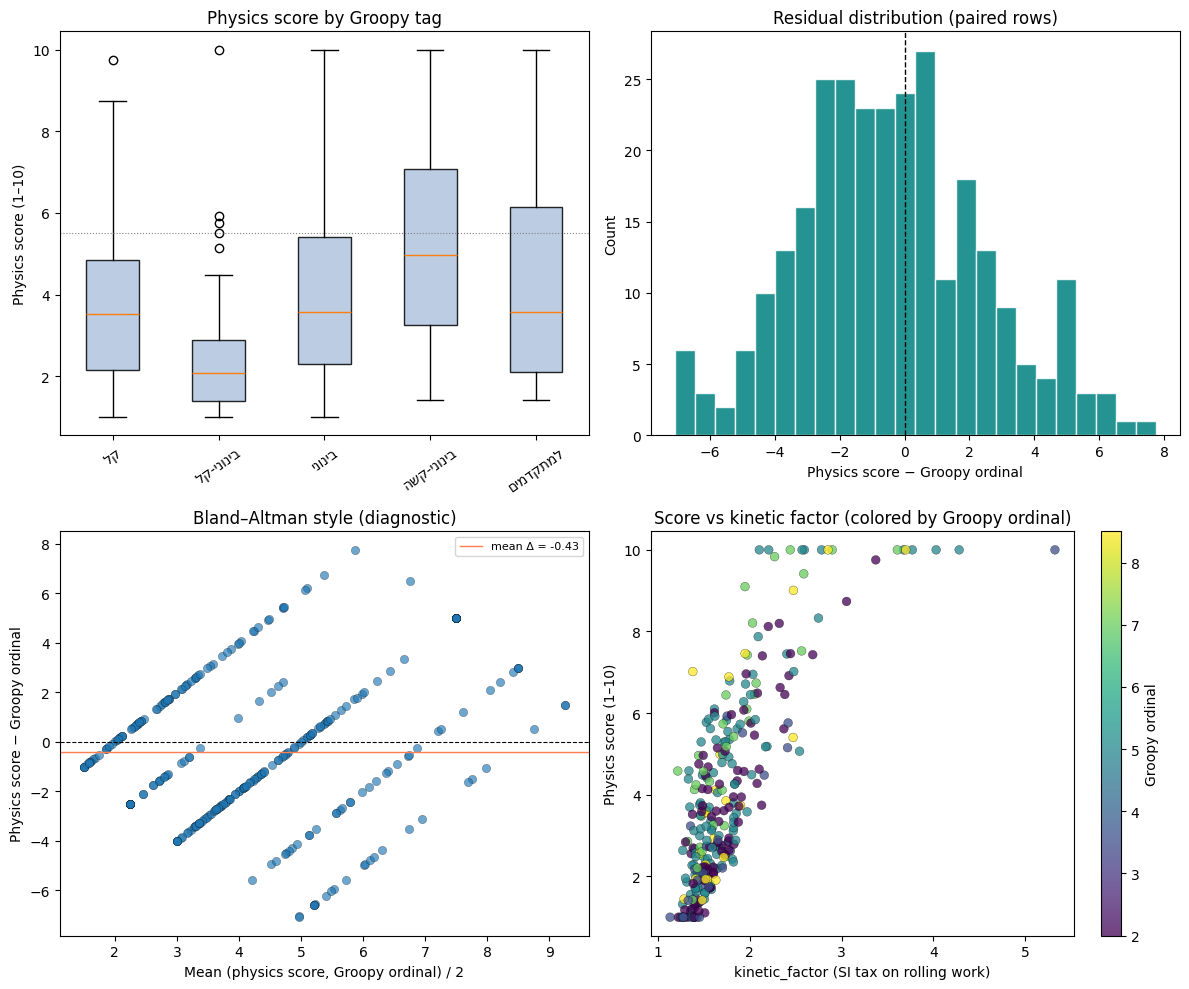

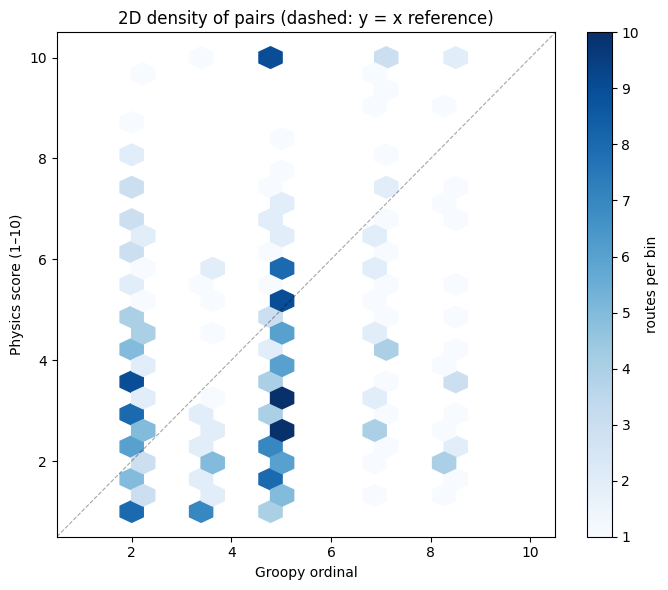

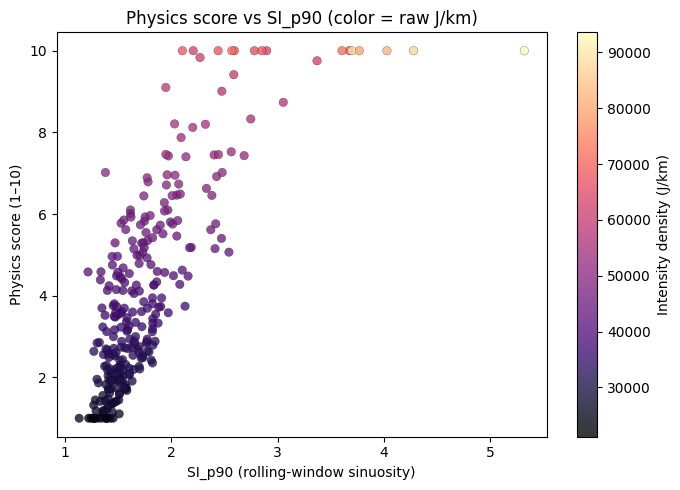

Physics score by Groopy tag (mean ± std, n):
  קל: 3.76 ± 2.08  (n=83)
  בינוני-קל: 2.72 ± 2.06  (n=29)
  בינוני: 4.16 ± 2.43  (n=112)
  בינוני-קשה: 5.40 ± 2.60  (n=35)
  למתקדמים: 4.37 ± 2.74  (n=23)


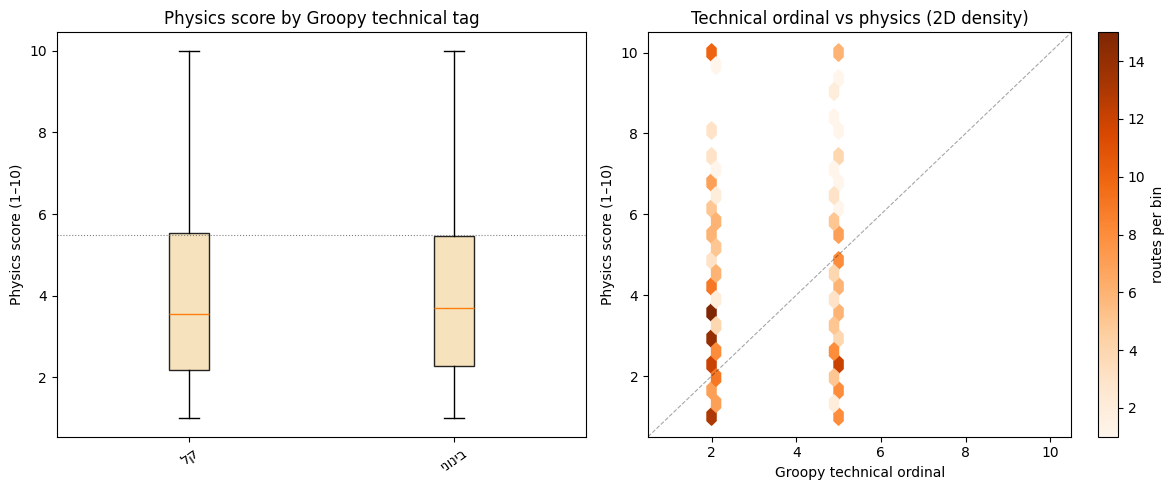

Physics score by Groopy technical tag (mean ± std, n):
  קל: 4.07 ± 2.43  (n=158)
  בינוני: 4.16 ± 2.45  (n=112)


In [125]:
# Paired rows: same rules as scatter / correlation (self-contained)
try:
    from bidi.algorithm import get_display as _bidi_display
except ImportError:
    def _bidi_display(s: str) -> str:
        return s

_GROOPY_ORD = {
    "קל": 2.0,
    "מתאים למתחילים": 2.0,
    "בינוני-קל": 3.5,
    "בינוני": 5.0,
    "בינוני-קשה": 7.0,
    "למתקדמים": 8.5,
}


def _groopy_to_ord(s) -> float | None:
    if s is None or (isinstance(s, float) and pd.isna(s)):
        return None
    t = str(s).strip()
    if not t or t.lower() == "nan":
        return None
    return _GROOPY_ORD.get(t)


_dc = res.copy()
_dc["groopy_ord"] = _dc["difficulty_groopy"].map(_groopy_to_ord)
_dc["technical_ord"] = _dc["difficulty_technical"].map(_groopy_to_ord)
pair = _dc.dropna(subset=["groopy_ord", "physics_score_1_10"]).copy()
pair = pair[np.isfinite(pair["groopy_ord"]) & np.isfinite(pair["physics_score_1_10"])]

if len(pair) < 3:
    print("Need at least 3 paired rows for diagnostics; got", len(pair))
else:
    cat_order = [k for k in _GROOPY_ORD if k in pair["difficulty_groopy"].unique()]
    pair["difficulty_groopy"] = pd.Categorical(pair["difficulty_groopy"], categories=cat_order, ordered=True)

    resid = pair["physics_score_1_10"].to_numpy(dtype=float) - pair["groopy_ord"].to_numpy(dtype=float)
    mean_ab = 0.5 * (
        pair["physics_score_1_10"].to_numpy(dtype=float) + pair["groopy_ord"].to_numpy(dtype=float)
    )

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # 1) Boxplot: physics score by Groopy label (separation check)
    ax = axes[0, 0]
    data_box = []
    labels_short = []
    for lab in cat_order:
        vals = pair.loc[pair["difficulty_groopy"] == lab, "physics_score_1_10"].dropna().values
        if len(vals) == 0:
            continue
        data_box.append(vals)
        raw_lbl = lab[:12] + "…" if len(lab) > 12 else lab
        labels_short.append(_bidi_display(raw_lbl))
    bp = ax.boxplot(data_box, tick_labels=labels_short, patch_artist=True)
    for patch in bp["boxes"]:
        patch.set(facecolor="lightsteelblue", alpha=0.85)
    ax.axhline(5.5, color="gray", linestyle=":", linewidth=0.8)
    ax.set_ylabel("Physics score (1–10)")
    ax.set_title("Physics score by Groopy tag")
    ax.tick_params(axis="x", rotation=35)

    # 2) Residual (physics − ordinal): how often we disagree
    ax = axes[0, 1]
    ax.hist(resid, bins=24, color="teal", edgecolor="white", alpha=0.85)
    ax.axvline(0.0, color="black", linestyle="--", linewidth=1)
    ax.set_xlabel("Physics score − Groopy ordinal")
    ax.set_ylabel("Count")
    ax.set_title("Residual distribution (paired rows)")

    # 3) Bland–Altman style: difference vs average (both on 1–10-ish scale)
    ax = axes[1, 0]
    ax.scatter(mean_ab, resid, alpha=0.65, s=36, edgecolors="k", linewidths=0.25)
    ax.axhline(0.0, color="black", linestyle="--", linewidth=0.8)
    rm = float(np.nanmean(resid))
    ax.axhline(rm, color="coral", linestyle="-", linewidth=1, label=f"mean Δ = {rm:.2f}")
    ax.legend(loc="best", fontsize=8)
    ax.set_xlabel("Mean (physics score, Groopy ordinal) / 2")
    ax.set_ylabel("Physics score − Groopy ordinal")
    ax.set_title("Bland–Altman style (diagnostic)")

    # 4) Internal consistency: tortuosity tax vs outcome
    ax = axes[1, 1]
    sc = ax.scatter(
        pair["kinetic_factor"],
        pair["physics_score_1_10"],
        c=pair["groopy_ord"],
        cmap="viridis",
        alpha=0.75,
        s=40,
        edgecolors="k",
        linewidths=0.25,
    )
    plt.colorbar(sc, ax=ax, label="Groopy ordinal")
    ax.set_xlabel("kinetic_factor (SI tax on rolling work)")
    ax.set_ylabel("Physics score (1–10)")
    ax.set_title("Score vs kinetic factor (colored by Groopy ordinal)")

    plt.tight_layout()
    plt.show()

    # Hexbin: crowding in Groopy ordinal × physics score plane
    fig2, ax2 = plt.subplots(figsize=(7, 6))
    hb = ax2.hexbin(
        pair["groopy_ord"],
        pair["physics_score_1_10"],
        gridsize=(14, 14),
        cmap="Blues",
        mincnt=1,
    )
    plt.colorbar(hb, ax=ax2, label="routes per bin")
    ax2.plot([0.5, 10.5], [0.5, 10.5], "k--", alpha=0.35, linewidth=0.8)
    ax2.set_xlim(0.5, 10.5)
    ax2.set_ylim(0.5, 10.5)
    ax2.set_xlabel("Groopy ordinal")
    ax2.set_ylabel("Physics score (1–10)")
    ax2.set_title("2D density of pairs (dashed: y = x reference)")
    plt.tight_layout()
    plt.show()

    # SI_p90 vs physics score (path sinuosity before kinetic_factor)
    fig3, ax3 = plt.subplots(figsize=(7, 5))
    sc3 = ax3.scatter(
        pair["si_p90"],
        pair["physics_score_1_10"],
        c=pair["intensity_density_J_per_km"],
        cmap="magma",
        alpha=0.78,
        s=38,
        edgecolors="k",
        linewidths=0.2,
    )
    plt.colorbar(sc3, ax=ax3, label="Intensity density (J/km)")
    ax3.set_xlabel("SI_p90 (rolling-window sinuosity)")
    ax3.set_ylabel("Physics score (1–10)")
    ax3.set_title("Physics score vs SI_p90 (color = raw J/km)")
    plt.tight_layout()
    plt.show()

    # Summary table: mean ± std physics score per tag
    summ = (
        pair.groupby("difficulty_groopy", observed=False)["physics_score_1_10"]
        .agg(["count", "mean", "std"])
        .reindex(cat_order)
    )
    print("Physics score by Groopy tag (mean ± std, n):")
    for lab in cat_order:
        row = summ.loc[lab]
        if pd.isna(row["count"]) or row["count"] == 0:
            continue
        print(
            f"  {lab!s}: {row['mean']:.2f} ± {row['std']:.2f}  (n={int(row['count'])})"
        )

    # Technical difficulty: boxplot + hexbin (same ordinal mapping as scatter cell)
    pair_t = _dc.dropna(subset=["technical_ord", "physics_score_1_10"]).copy()
    pair_t = pair_t[
        np.isfinite(pair_t["technical_ord"]) & np.isfinite(pair_t["physics_score_1_10"])
    ]
    if len(pair_t) >= 3:
        cat_order_t = [k for k in _GROOPY_ORD if k in pair_t["difficulty_technical"].unique()]
        pair_t["difficulty_technical"] = pd.Categorical(
            pair_t["difficulty_technical"], categories=cat_order_t, ordered=True
        )

        figt, axst = plt.subplots(1, 2, figsize=(12, 5))
        ax = axst[0]
        data_box_t = []
        labels_short_t = []
        for lab in cat_order_t:
            vals = pair_t.loc[pair_t["difficulty_technical"] == lab, "physics_score_1_10"].dropna().values
            if len(vals) == 0:
                continue
            data_box_t.append(vals)
            raw_lbl = lab[:12] + "…" if len(lab) > 12 else lab
            labels_short_t.append(_bidi_display(raw_lbl))
        bp = ax.boxplot(data_box_t, tick_labels=labels_short_t, patch_artist=True)
        for patch in bp["boxes"]:
            patch.set(facecolor="wheat", alpha=0.85)
        ax.axhline(5.5, color="gray", linestyle=":", linewidth=0.8)
        ax.set_ylabel("Physics score (1–10)")
        ax.set_title("Physics score by Groopy technical tag")
        ax.tick_params(axis="x", rotation=35)

        ax = axst[1]
        hb = ax.hexbin(
            pair_t["technical_ord"],
            pair_t["physics_score_1_10"],
            gridsize=(14, 14),
            cmap="Oranges",
            mincnt=1,
        )
        plt.colorbar(hb, ax=ax, label="routes per bin")
        ax.plot([0.5, 10.5], [0.5, 10.5], "k--", alpha=0.35, linewidth=0.8)
        ax.set_xlim(0.5, 10.5)
        ax.set_ylim(0.5, 10.5)
        ax.set_xlabel("Groopy technical ordinal")
        ax.set_ylabel("Physics score (1–10)")
        ax.set_title("Technical ordinal vs physics (2D density)")
        plt.tight_layout()
        plt.show()

        summ_t = (
            pair_t.groupby("difficulty_technical", observed=False)["physics_score_1_10"]
            .agg(["count", "mean", "std"])
            .reindex(cat_order_t)
        )
        print("Physics score by Groopy technical tag (mean ± std, n):")
        for lab in cat_order_t:
            row = summ_t.loc[lab]
            if pd.isna(row["count"]) or row["count"] == 0:
                continue
            print(
                f"  {lab!s}: {row['mean']:.2f} ± {row['std']:.2f}  (n={int(row['count'])})"
            )
